## feature engineering 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import numpy as np 

In [2]:
NOTEBOOK_DIR=Path.cwd()
ROOT_DIR=NOTEBOOK_DIR.parent
DIR_DATA=ROOT_DIR/"data"
DIR_DATA_RAW=DIR_DATA/"raw"
DIR_DATA_PROCESSED=DIR_DATA/"processed"
DIR_DATA

PosixPath('/Users/essalehachraf/Market-Neutral-Alpha-Prediction/data')

In [3]:
X_train_processed=pd.read_csv(DIR_DATA_PROCESSED/"x_train_processed.csv",index_col="ID")
display(X_train_processed)
#print(f"{int(X_train_processed['SECTOR'].min()) , int(X_train_processed['SECTOR'].max())}")

Y_train=pd.read_csv(DIR_DATA_RAW/"y_train.csv",index_col="ID")
print(f" y_traine has {Y_train.size} rows")

,DATE,STOCK,INDUSTRY,INDUSTRY_GROUP,SECTOR,SUB_INDUSTRY,RET_1,VOLUME_1,RET_2,VOLUME_2,...,RET_16_missing,VOLUME_16_missing,RET_17_missing,VOLUME_17_missing,RET_18_missing,VOLUME_18_missing,RET_19_missing,VOLUME_19_missing,RET_20_missing,VOLUME_20_missing
ID,,,,,,,,,,,,,,,,,,,,,
0,0,2,18,5,3,44,-0.015748,0.147931,-0.015504,0.179183,...,0,0,0,0,0,0,0,0,0,0
1,0,3,43,15,6,104,0.003984,-0.333778,-0.090580,-0.332121,...,0,1,0,1,0,1,0,1,0,1
2,0,4,57,20,8,142,0.000440,-0.096282,-0.058896,0.084771,...,0,0,0,0,0,0,0,0,0,0
3,0,8,1,1,1,2,0.031298,-0.429540,0.007756,-0.089919,...,0,0,0,0,0,0,0,0,0,0
4,0,14,36,12,5,92,0.027273,-0.847155,-0.039302,-0.943033,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418590,223,5703,32,10,4,77,0.021843,-0.217823,-0.021703,-0.125333,...,0,0,0,0,0,0,0,0,0,0
418591,223,5705,35,12,5,91,-0.006920,-0.375251,0.000000,-0.029437,...,0,0,0,0,0,0,0,0,0,0
418592,223,5709,2,1,1,5,0.021869,-0.978856,-0.005929,-1.026267,...,0,0,0,0,0,0,0,0,0,0


 y_traine has 418595 rows


In [26]:
X_train_processed["DATE"].describe()

count    418595.000000
mean        108.659002
std          61.891642
min           0.000000
25%          56.000000
50%         104.000000
75%         161.000000
max         223.000000
Name: DATE, dtype: float64

## Starting point feature engineering:

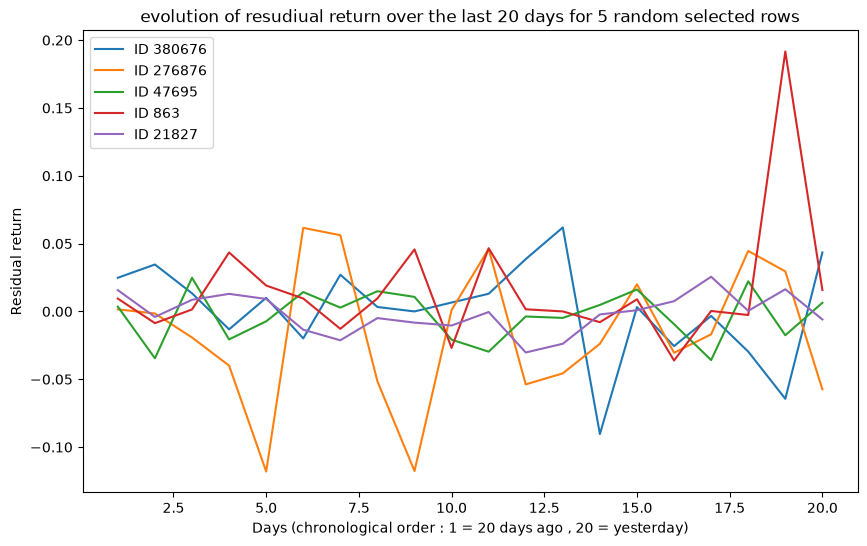

In [4]:
ret_i=[f"RET_{i}" for i in range(20,0,-1)]
df_ret20_ret1=X_train_processed[ret_i]

sample_rows=df_ret20_ret1.sample(n=5,random_state=42)

plt.figure(figsize=(10,6))
for idx, row in sample_rows.iterrows():
    y=row[ret_i].values 
    x=range(1,21)
    plt.plot(x,y,label=f"ID {idx}")
plt.xlabel("Days (chronological order : 1 = 20 days ago , 20 = yesterday)")
plt.ylabel("Residual return")
plt.title("evolution of resudiual return over the last 20 days for 5 random selected rows")
plt.legend()

- We can see that there's no particular pattern between the 5 stocks (no shared spike or dip at the same time), this tells us that residual returns are stock specific **which is what residual is supposed to look like** no market effect 

- most residual returns set in a tha band of +- 0.05 with occasional large spikes 

- **this confirms that compressing noise into more informative features is mandatory**, we re going to use agregate statistics(volatility, momentum etc)

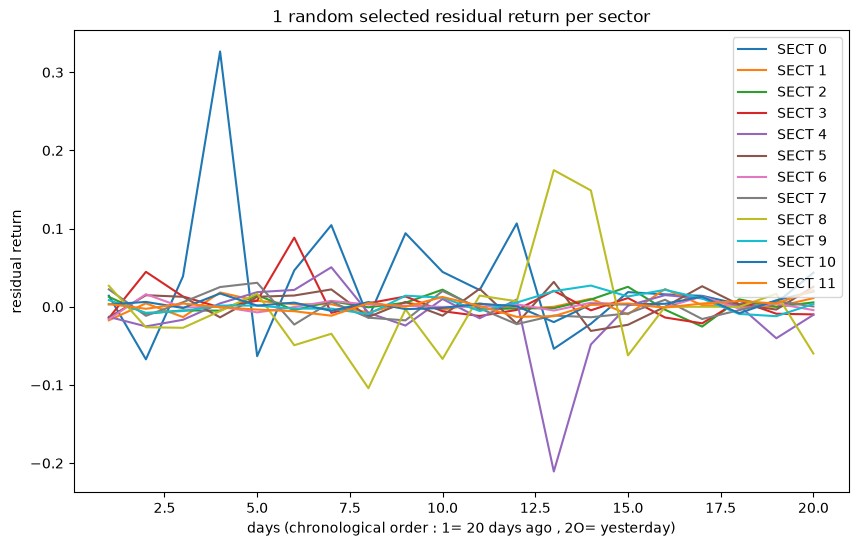

In [5]:
ret_i_sector= pd.concat([df_ret20_ret1, X_train_processed["SECTOR"]], axis=1) 
sectors=ret_i_sector["SECTOR"].unique()
row_sample_by_sector= ret_i_sector.groupby("SECTOR").sample(n=1, random_state=42)

plt.figure(figsize=(10,6))
for idx, row in row_sample_by_sector.iterrows():
    y=row[ret_i].values
    x=range(1,21)
    plt.plot(x,y,label=f"SECT {int(row['SECTOR'])}")
    
plt.xlabel("days (chronological order : 1= 20 days ago , 2O= yesterday)")
plt.ylabel("residual return")
plt.title("1 random selected residual return per sector")
plt.legend()


- sector (alone) doesn't creat a visually distinguishable shape in the return path 
- if it does it can be with some agregate statistics

**since the signal is very week here, in order to not spend hours in FE and realise that features we creat are just noise... we're going to follow a loop : creature a feature -> evaluating corrrelation/relationship with the target --> keep or discard? --> move on to the next**

## 1.a Short term volatility : std of ret_1... ret_5

In [6]:
ret_1_5=[f"RET_{i}" for i in range(1,6)]
df_ret20_ret1["RET_STD_5"]=df_ret20_ret1[ret_1_5].std(axis=1)
df_ret20_ret1

,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,RET_12,RET_11,...,RET_9,RET_8,RET_7,RET_6,RET_5,RET_4,RET_3,RET_2,RET_1,RET_STD_5
ID,,,,,,,,,,,,,,,,,,,,,
0,-0.002155,-0.012959,0.008752,0.003254,0.059459,-0.028571,-0.049370,0.027624,0.030108,0.013570,...,0.134146,-0.018433,-0.017215,0.014331,0.016483,-0.014672,0.010972,-0.015504,-0.015748,0.016027
1,-0.034722,-0.028777,-0.018518,0.003774,0.015413,-0.004073,-0.052044,-0.019608,-0.028000,-0.008230,...,0.158731,0.023973,-0.026756,-0.006873,-0.038062,-0.025540,0.018826,-0.090580,0.003984,0.042498
2,-0.006867,-0.012101,-0.006562,-0.017612,0.008964,-0.007552,-0.002686,-0.009426,0.028093,-0.012781,...,-0.006342,-0.002979,-0.023047,0.027522,0.009354,0.024852,-0.009042,-0.058896,0.000440,0.031757
3,-0.036745,-0.013520,-0.001468,0.033824,-0.031769,0.021057,0.000479,-0.010067,0.007264,0.007693,...,0.014146,-0.004329,-0.043962,-0.002021,0.003544,-0.019677,-0.004632,0.007756,0.031298,0.018668
4,-0.040817,0.004256,0.004237,-0.012659,-0.038461,-0.026667,0.095891,-0.041667,-0.004348,-0.008734,...,-0.008621,-0.017391,-0.026549,0.018182,0.022321,0.000000,0.000000,-0.039302,0.027273,0.026294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418590,0.031174,-0.058448,0.008205,0.007785,0.003160,-0.001750,-0.017532,-0.004996,0.019369,-0.003519,...,0.020077,-0.008287,-0.020195,0.028785,0.001727,0.021379,0.011141,-0.021703,0.021843,0.017999
418591,-0.011073,-0.015396,0.007819,-0.016221,0.007169,-0.000711,-0.004986,-0.001432,-0.003584,0.000000,...,0.007863,0.000000,-0.013476,0.012941,0.009226,0.009143,0.006968,0.000000,-0.006920,0.007023
418592,0.098607,-0.082927,-0.069148,0.029714,0.001110,0.013304,0.024070,-0.001068,0.047058,0.032687,...,0.001890,0.024928,-0.011628,-0.008824,-0.015826,0.006030,0.010989,-0.005929,0.021869,0.014682


- let's check the correlation with the target... since our target is binary (the signe of tomorrow's residual return), we're doing a special case of pearson correlation called point biserial correlation 

In [7]:
# since the target is on another csv we will have to creat a new df with the 2 variables
df_target_std_ret5=pd.concat(
    [df_ret20_ret1["RET_STD_5"],Y_train["RET"]],
    axis=1
    )
df_target_std_ret5


,RET_STD_5,RET
ID,,
0,0.016027,True
1,0.042498,True
2,0.031757,False
3,0.018668,False
4,0.026294,False
...,...,...
418590,0.017999,False
418591,0.007023,False
418592,0.014682,True


## point biserial correlation

In [8]:
corr=df_target_std_ret5['RET_STD_5'].corr(df_target_std_ret5['RET'])
float(corr)

-0.011872638688746114

- almost non llineaire relationship

- We have a negative correlation, a week negative lineaire relationship between the short term volatility and the binary target... let's compare the distribution of target=TRUE and target=FALSE
- even small negative correaltion can hide differences between two classes :)
meaning we're answering does volatility look different when tomorrow's residual looks potive or negative ?

In [9]:
df_target_std_ret5.groupby("RET")["RET_STD_5"].agg(["count","mean","median","std"])

,count,mean,median,std
RET,,,,
False,209749,0.023217,0.017633,0.021381
True,208846,0.022700,0.016905,0.022110


- We can see that the statisitics of both classes are slightly the same, that's evidence that short term volatility doesn't separe the classes...

Text(0.5, 0.98, '')

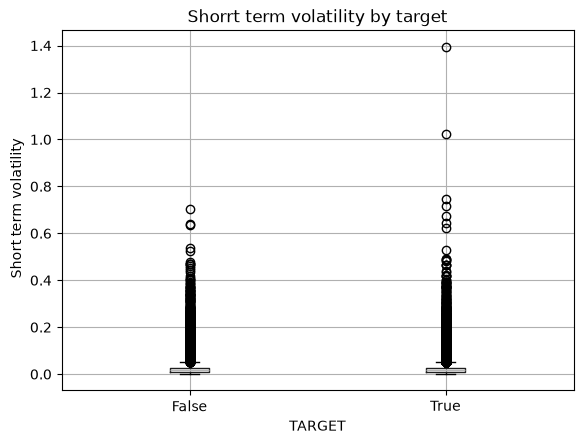

In [10]:
df_target_std_ret5.boxplot(
    column="RET_STD_5",
    by="RET"
)
plt.xlabel("TARGET")
plt.ylabel(" Short term volatility")
plt.title("Shorrt term volatility by target")
plt.suptitle("")
#plt.ylim(0,0.04)

- the boxplot shows that the distribution of the classes is slightly identical positive return has several outliers with the most extreme (at y=1.4 and 1.0 ), we can conclude that the short term voalitility doesn't separate classes ... it shows non lineair relationship with the target but we will keept it because ***tree bases models can capture non lineaire relationships or interaction effects with other feature***, so we will let feature importance decide ...

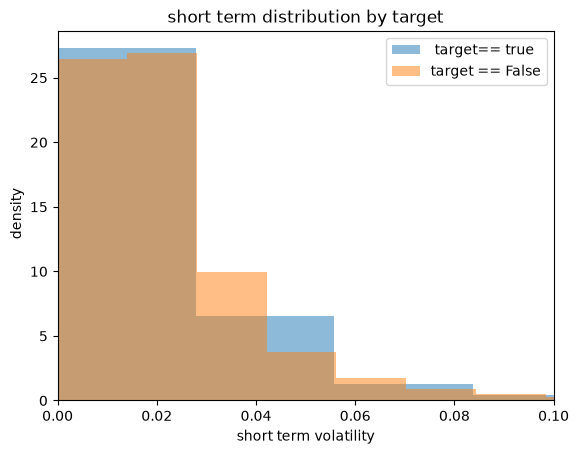

In [11]:
plt.hist(
    df_target_std_ret5[df_target_std_ret5["RET"]==True]["RET_STD_5"],
    bins=50,
    alpha=0.5,
    label=" target== true",
    density="True",
    #histtype="step"
)
plt.hist(
    df_target_std_ret5[df_target_std_ret5["RET"]==False]["RET_STD_5"],
    bins=50,
    alpha=0.5,
    label="target == False",
    density=True,
   # histtype="step"
)

plt.xlabel("short term volatility")
plt.ylabel(" density")
plt.title("short term distribution by target")
plt.xlim(0,0.1)
plt.legend()

- distribution density histogram show overllaping almost perfectly between classes i.e not shape diffences neither

- let's do the same analysis on longterm volatility

# 1.b long term vol :  std across its ret1,..., ret 20 

In [12]:
df_ret20_ret1["RET_STD_20"]=df_ret20_ret1.std(axis=1)
#df_ret20_ret1


In [13]:
df_target_std_ret20= pd.concat(
    [df_ret20_ret1["RET_STD_20"],Y_train["RET"]],
    axis=1
)
#df_target_std_ret20

In [14]:
corr_long_vol_target=df_target_std_ret20["RET"].corr(df_target_std_ret20["RET_STD_20"])
float(corr_long_vol_target)

-0.0071736809976378525

- almost non linear relation ship between long term volatility and the target... ( low negative relationship )
- correlation between the short term volatility and the target is higher that the long term volatility with the target... which is normal recent fluctuation of the market give more information on next move than old fluctuation...
- let's see if tomorrow's volatility looks different when tomorrow's return is positive or negative ...

In [15]:
df_target_std_ret20.groupby(df_target_std_ret20['RET'])['RET_STD_20'].aggregate(["count","mean","median","std"])

,count,mean,median,std
RET,,,,
False,209749,0.025520,0.020722,0.019251
True,208846,0.024884,0.019999,0.059735


- first three statistics are almost the same regardless of target output ... 
- we can see that standard deviation is higher when the return is positive rather than when it's negative ... meaning the spread of the variation around the mean is higher when the return is positive 
- we need to visualise the distribution of the target and the new feature 

(0.0, 0.8)

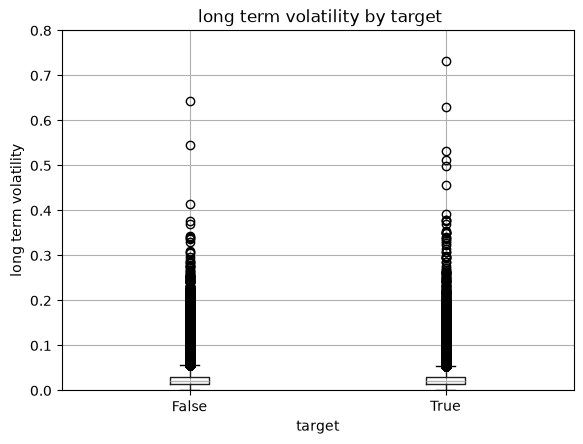

In [16]:
df_target_std_ret20.boxplot(
    column='RET_STD_20',
    by='RET'
    
)
plt.xlabel ("target")
plt.ylabel(" long term volatility ")
plt.title(" long term volatility by target")
plt.suptitle("")
plt.ylim(0,0.8)

- as before the distribution of the classes are nearly symetrical ( as statstics confirmed it ), we have outliers in two classes with extrem outliers on both sides (higher on True class 0.72 vs 0.64 in the left class) ... we can conclude that thre's no lineaire relationship between the target and long term volatility... 
- despite that fact we're not gonna drop the feature because based tree models are capable to capture non linearity or features interactions... 
- We re going to let feature importance do the job

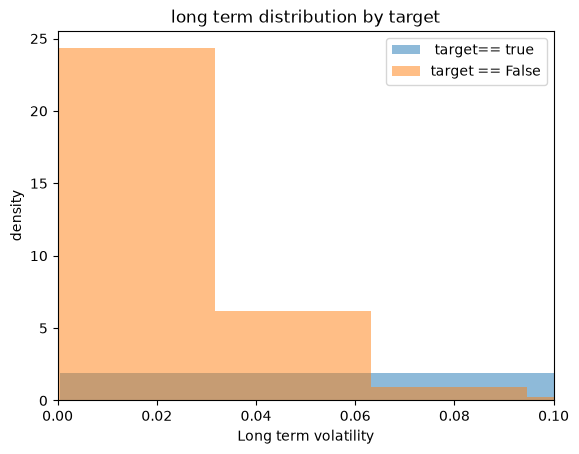

In [17]:
plt.hist(
    df_target_std_ret20[df_target_std_ret20["RET"]==True]["RET_STD_20"],
    bins=50,
    alpha=0.5,
    label=" target== true",
    density="True",
    #histtype="step"
)
plt.hist(
    df_target_std_ret20[df_target_std_ret20["RET"]==False]["RET_STD_20"],
    bins=50,
    alpha=0.5,
    label="target == False",
    density=True,
   # histtype="step"
)

plt.xlabel("Long term volatility")
plt.ylabel(" density ")
plt.title("long term distribution by target")
plt.xlim(0,0.1)
plt.legend()

## 2. momentum: is the RECENT trend up or down overall

- as a first pass we 're going to use the median (in order to answer what's a typical day looks like), then use the mean (what's the net effect including large movements), of RET1,..,RET20 then RET1,..,RET5 
- then we gonna give exponential weights in order to give more importance to recent day's since they capture more information about the future then old day's do 


In [24]:
ret_20=[f"RET_{i}" for i in range(1,21)]
ret_5=[f"RET_{i}" for i in range(1,6)]
df_ret20_ret1["RET_mean_20"]= df_ret20_ret1[ret_20].mean(axis=1)
df_ret20_ret1["RET_mean_5"]= df_ret20_ret1[ret_5].mean(axis=1)
df_ret20_ret1


,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,RET_12,RET_11,...,RET_4,RET_3,RET_2,RET_1,RET_STD_5,RET_STD_20,long_Momentum,short_Momentum,RET_mean_20,RET_mean_5
ID,,,,,,,,,,,,,,,,,,,,,
0,-0.002155,-0.012959,0.008752,0.003254,0.059459,-0.028571,-0.049370,0.027624,0.030108,0.013570,...,-0.014672,0.010972,-0.015504,-0.015748,0.016027,0.053263,0.017984,-0.003694,0.016318,-0.003694
1,-0.034722,-0.028777,-0.018518,0.003774,0.015413,-0.004073,-0.052044,-0.019608,-0.028000,-0.008230,...,-0.025540,0.018826,-0.090580,0.003984,0.042498,0.048715,-0.000919,-0.026274,-0.005572,-0.026274
2,-0.006867,-0.012101,-0.006562,-0.017612,0.008964,-0.007552,-0.002686,-0.009426,0.028093,-0.012781,...,0.024852,-0.009042,-0.058896,0.000440,0.031757,0.023920,0.001582,-0.006658,-0.001043,-0.006658
3,-0.036745,-0.013520,-0.001468,0.033824,-0.031769,0.021057,0.000479,-0.010067,0.007264,0.007693,...,-0.019677,-0.004632,0.007756,0.031298,0.018668,0.020854,-0.001071,0.003658,-0.003154,0.003658
4,-0.040817,0.004256,0.004237,-0.012659,-0.038461,-0.026667,0.095891,-0.041667,-0.004348,-0.008734,...,0.000000,0.000000,-0.039302,0.027273,0.026294,0.031905,-0.000583,0.002059,-0.003551,0.002059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418590,0.031174,-0.058448,0.008205,0.007785,0.003160,-0.001750,-0.017532,-0.004996,0.019369,-0.003519,...,0.021379,0.011141,-0.021703,0.021843,0.017999,0.020803,0.003613,0.006877,0.002034,0.006877
418591,-0.011073,-0.015396,0.007819,-0.016221,0.007169,-0.000711,-0.004986,-0.001432,-0.003584,0.000000,...,0.009143,0.006968,0.000000,-0.006920,0.007023,0.008783,0.000437,0.003683,-0.000310,0.003683
418592,0.098607,-0.082927,-0.069148,0.029714,0.001110,0.013304,0.024070,-0.001068,0.047058,0.032687,...,0.006030,0.010989,-0.005929,0.021869,0.014682,0.037124,0.007399,0.003427,0.005549,0.003427


In [29]:
df_target_mean20=pd.concat(
    [df_ret20_ret1["RET_mean_20"],Y_train["RET"]],
    axis=1
)
#df_target_mean20
corr_mean20_target= df_target_mean20["RET_mean_20"].corr(df_target_mean20["RET"])
float(corr_mean20_target)


-0.0086625614863653

In [33]:
df_target_mean20.groupby(df_target_mean20["RET"])["RET_mean_20"].aggregate(["count","mean","median","std"])

,count,mean,median,std
RET,,,,
False,209749,0.000723,0.000755,0.006797
True,208846,0.000526,0.000699,0.014571


(0.0, 0.4)

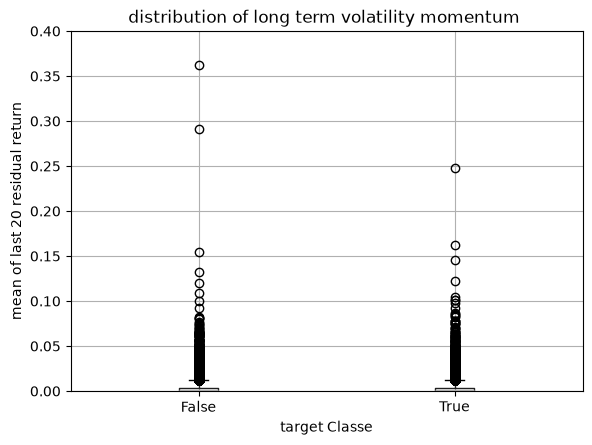

In [40]:
df_target_mean20.boxplot(
    column="RET_mean_20", 
    by="RET"
)
plt.xlabel(" target Classe ")
plt.ylabel("mean of last 20 residual return")
plt.title("distribution of long term volatility momentum ")
plt.suptitle("")
plt.ylim(0,0.4)



## DRAFT *************************************************

Text(0.5, 1.0, 'Long term volatility of stocks')

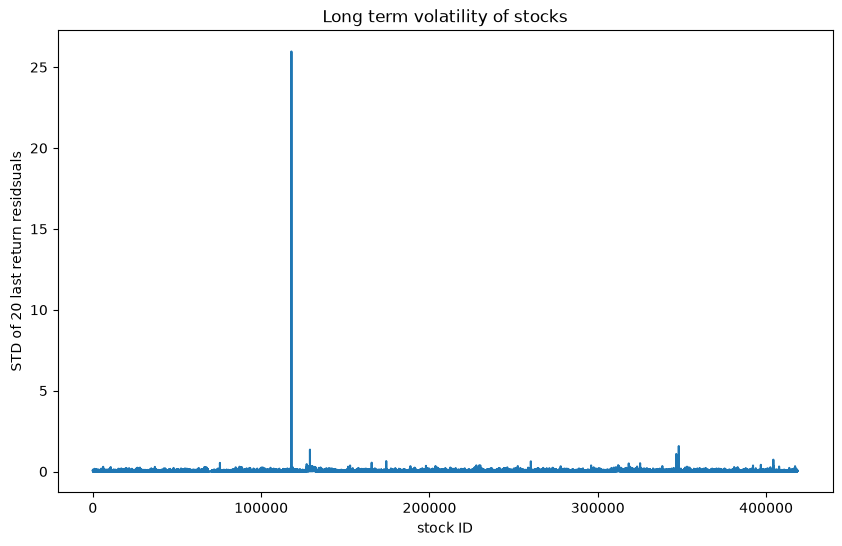

In [ ]:

plt.figure(figsize=(10,6))

plt.plot(df_ret20_ret1.index,df_ret20_ret1["RET_STD_20"])
    
plt.xlabel("stock ID")
plt.ylabel("STD of 20 last return residsuals")
plt.title("Long term volatility of stocks")


- We can see that the long term volatility is a bit stable over stocks and variates around 0 , there's a peak at stock 117974 with a std=26 

In [ ]:
long_term_vol_20=df_ret20_ret1["RET_STD_20"]
print(f"(id_max_vol,max_col) = {long_term_vol_20.idxmax(), int(long_term_vol_20.max())}")


(id_max_vol,max_col) = (117974, 25)


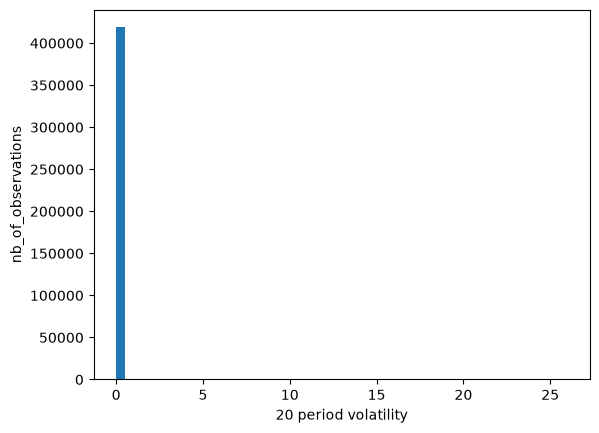

In [ ]:
#let's take a look to the distribution of the of volatilty 
plt.hist(df_ret20_ret1["RET_STD_20"], bins=50)
plt.xlabel("20 period volatility")
plt.ylabel("nb_of_observations")
plt.show()
